`TCS Stock Price Prediction Using Machine Learning Models`

#### Description:
* In the second part of the project, I used the cleaned and preprocessed TCS stock dataset to build predictive models. The goal was to forecast future stock prices based on historical trends and selected financial indicators.

* Machine learning algorithms were applied to learn patterns from past data and predict future price movements. This phase focused on model building, evaluation, and performance comparison.

## 1. Import Required Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load Dataset

In [2]:
data = pd.read_csv("TCS_cleaned_data.csv")
data.head()

,open,high,low,close,volume,Prev_Close,day_of_week,month
0,65.061065,66.947835,62.263442,62.783928,80424,65.516487,3,7
1,58.573539,64.131611,58.043755,63.666889,29280,62.783928,4,7
2,64.131618,65.590846,63.202175,64.912354,22272,63.666889,0,7
3,65.999807,67.105848,65.432849,65.683800,48160,64.912354,1,7
4,66.910660,68.778839,66.083452,67.375381,74376,65.683800,2,7


## 3. Feature scaling

In [3]:
X = data[['open', 'high', 'low', 'volume', 'Prev_Close', 'day_of_week', 'month']]
y = data['close']

In [4]:
sc = StandardScaler()
sc.fit_transform(X)

X = pd.DataFrame(sc.fit_transform(X), columns=X.columns)
X.head(5)

,open,high,low,volume,Prev_Close,day_of_week,month
0,-1.018858,-1.018656,-1.019853,-1.096761,-1.018445,0.714472,0.138859
1,-1.026681,-1.022018,-1.024995,-1.112340,-1.021745,1.422596,0.138859
2,-1.019979,-1.020276,-1.018709,-1.114474,-1.020679,-1.409900,0.138859
3,-1.017726,-1.018467,-1.015991,-1.106589,-1.019174,-0.701776,0.138859
4,-1.016627,-1.016469,-1.015198,-1.098603,-1.018243,0.006348,0.138859


## 4. Train Test Split

In [5]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

## 5. Model Apply

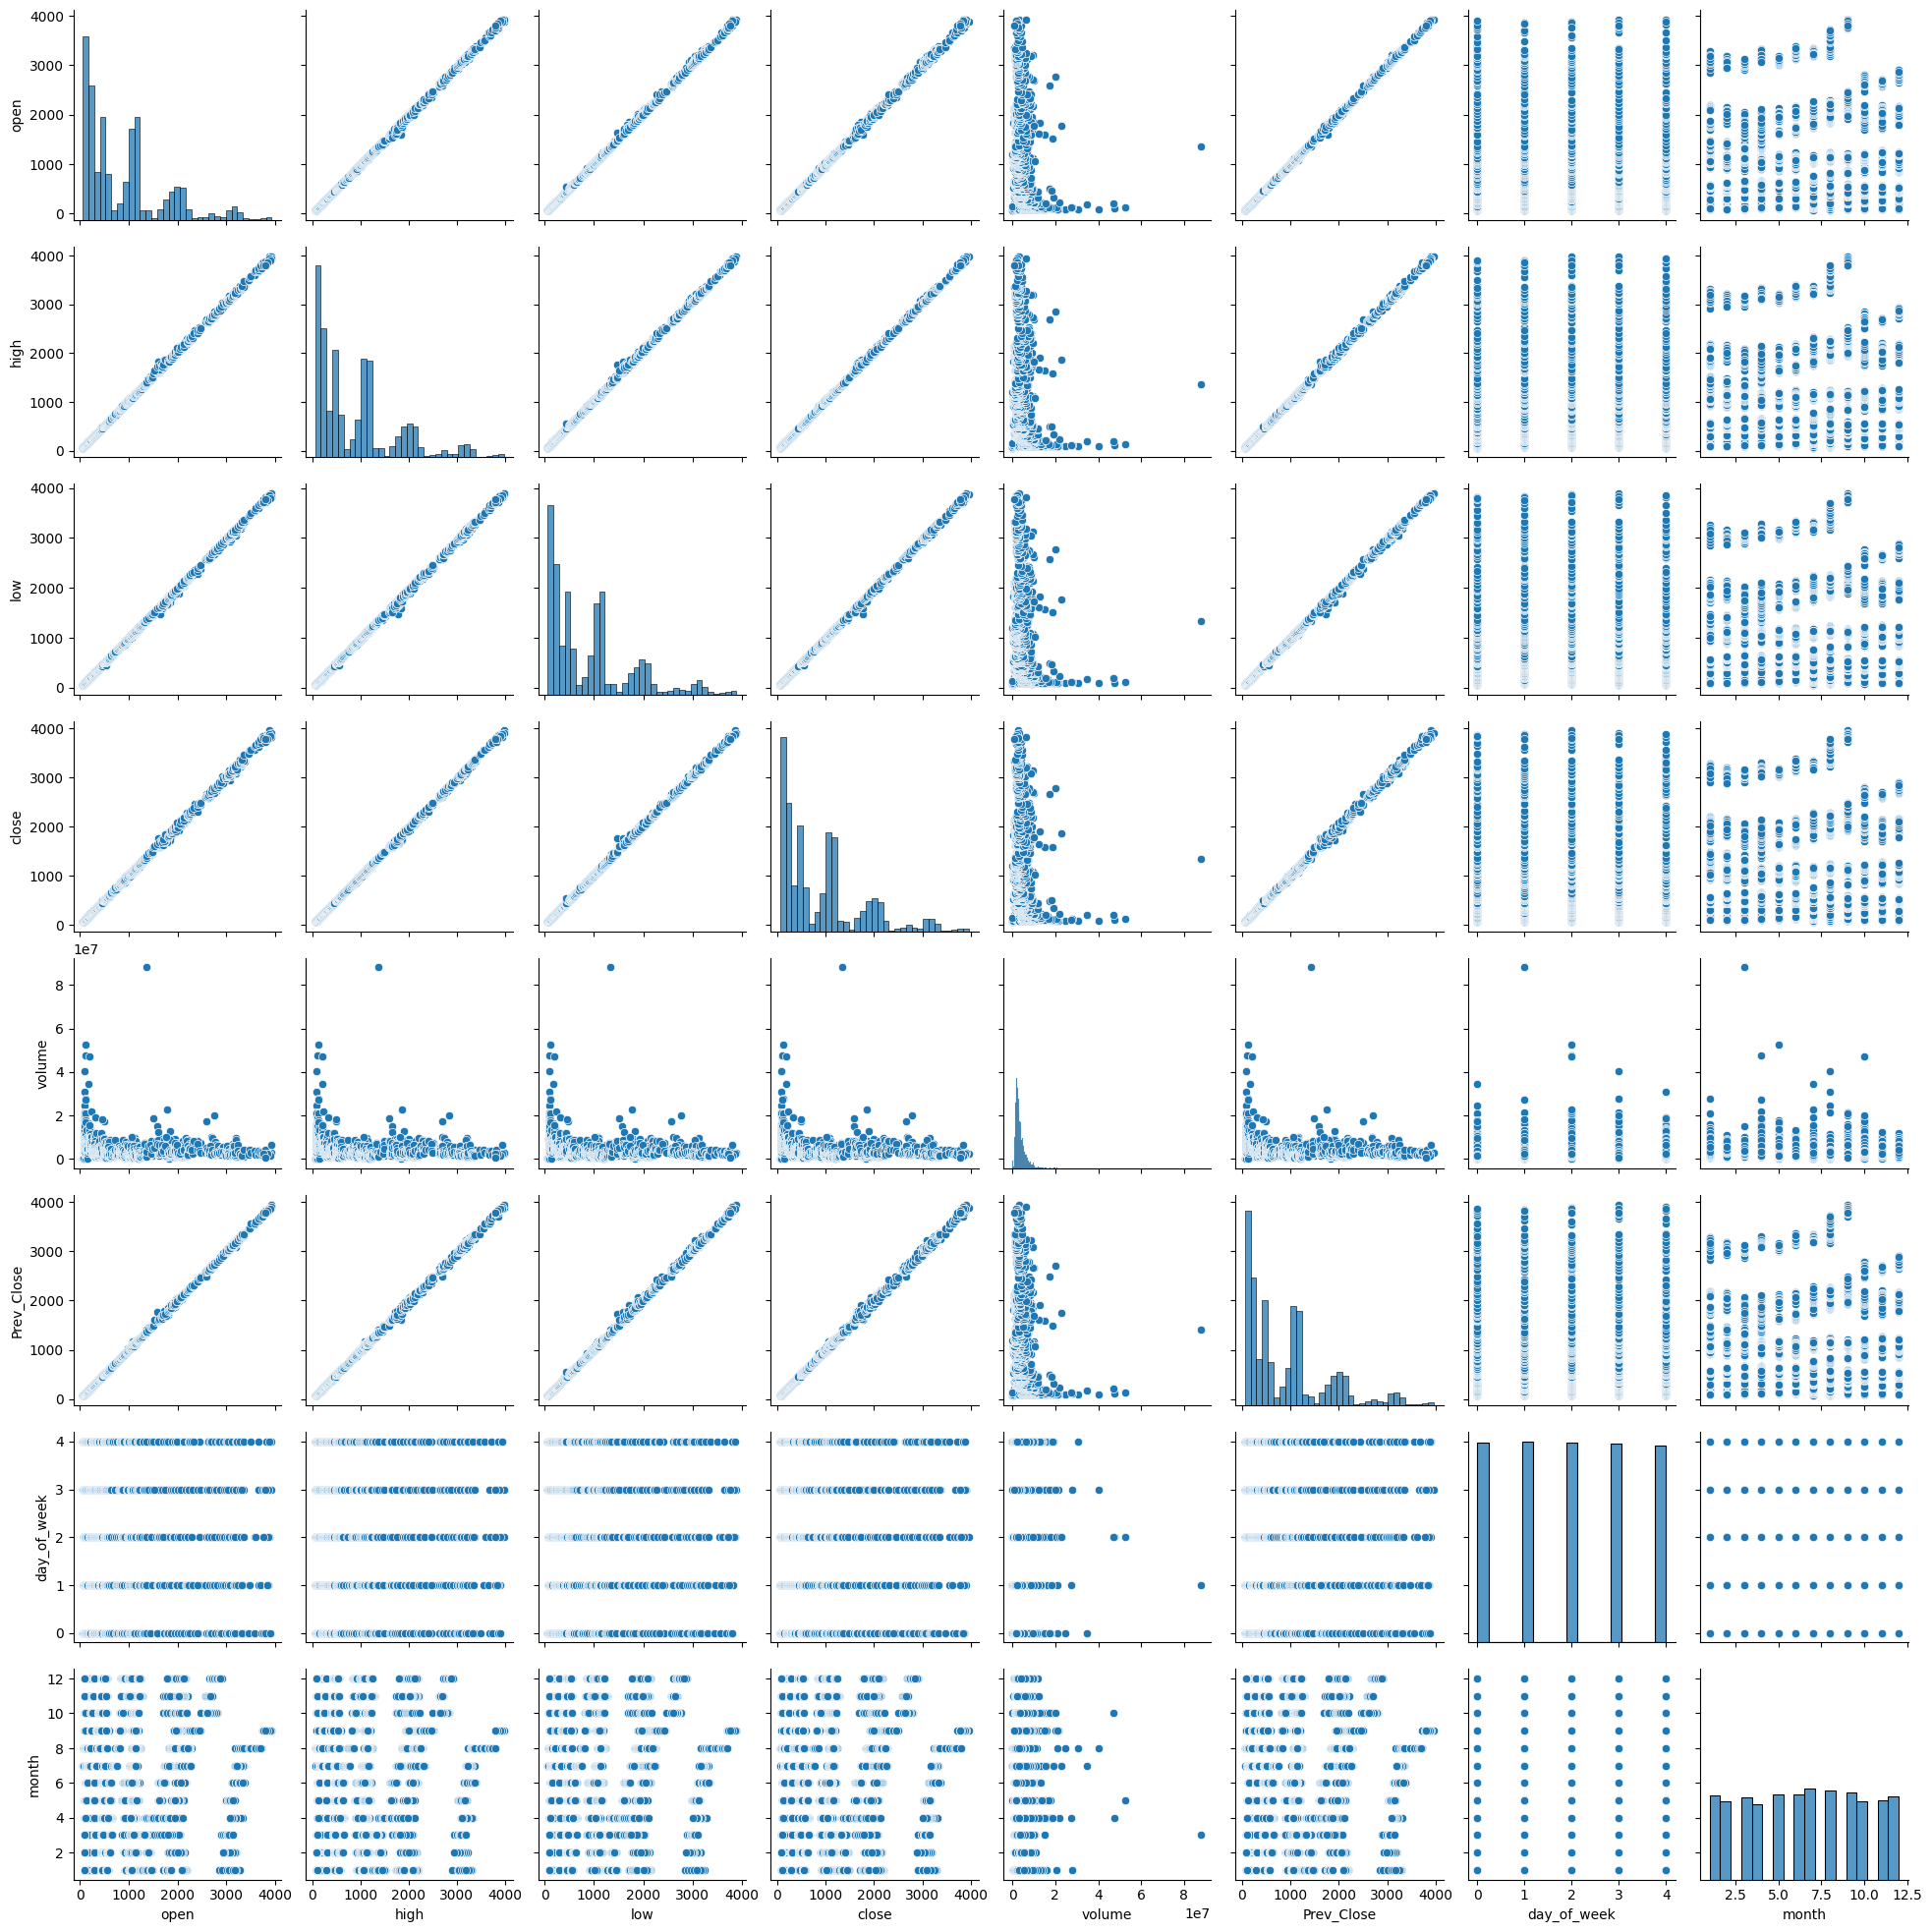

In [6]:
# lets see the behaviour of the data
sns.pairplot(data)
plt.show()

In [7]:
# Linear Regression Model
lr = LinearRegression()
lr.fit(X_train, y_train)
lr.score(X_test, y_test)*100 , lr.score(X_train, y_train)*100

(99.99266336228595, 99.99185637009495)

In [8]:
# Predictions
y_pred = lr.predict(X_test)

In [9]:
# Evaluation
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-Squared Score:", r2_score(y_test, y_pred))

Mean Squared Error: 47.43195837878139
R-Squared Score: 0.9999266336228595


In [10]:
# Display actual vs predicted values for the first 10 samples
comparison = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': y_pred.flatten()})
comparison.head(10)

,Actual,Predicted
0,1076.373169,1080.612458
1,212.650543,211.799012
2,1196.611084,1201.078115
3,520.407288,516.968493
4,629.135315,624.098252
5,158.007080,156.774582
6,916.317566,920.069866
7,100.460068,101.419204
8,1957.390869,1961.686666
9,475.842651,472.626245


## 6. Visualize Model Performance
* Plot predicted vs. actual values.
* Scatter plot to observe prediction accuracy

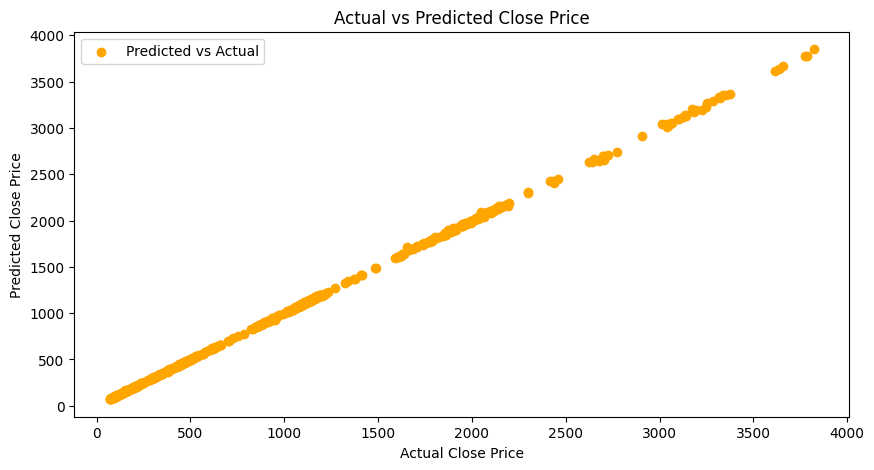

In [11]:
plt.figure(figsize=(10, 5))
plt.scatter(y_test, y_pred, color='orange', label='Predicted vs Actual')
plt.xlabel('Actual Close Price')
plt.ylabel('Predicted Close Price')
plt.title('Actual vs Predicted Close Price')
plt.legend()
plt.show()

## 7. Save the Model
* Save the trained model for future use.

In [12]:
import pickle
with open('TCS_Stock_Predictor.pkl', 'wb') as file:
    pickle.dump(lr, file)

print("Model Saved Successfully")

Model Saved Successfully


# `Explanation Summary`
* This project covers EDA, visualization, feature engineering, and prediction modeling
for TCS stock prices:
1. EDA provides insights into the stock's historical patterns.
2. Moving Averages help smooth out price trends.
3. Linear Regression is used to predict closing prices.
4. Evaluation metrics help validate the model’s accuracy, giving insight into its
reliability